In [ ]:
import os
import kagglehub

# 1. Feed your credentials directly to the environment
os.environ['KAGGLE_USERNAME'] = "timelordzzz"
os.environ['KAGGLE_KEY'] = "KGAT_5344fc8a054288a9f283b8f7b5d200af"

# 2. Stream a valid dataset cloud-to-cloud instantly
path = kagglehub.dataset_download("sazidthe1/data-science-salaries")
print("Dataset downloaded directly to cloud path:", path)

Using Colab cache for faster access to the 'data-science-salaries' dataset.
Dataset downloaded directly to cloud path: /kaggle/input/data-science-salaries


In [ ]:
import os

# List all the files inside the downloaded folder path
print(os.listdir(path))

['data_science_salaries.csv']


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:


# Combine the folder path and the file name dynamically
csv_file_path = os.path.join(path, "data_science_salaries.csv")

# Load it into a dataframe
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of your data
df.head()

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           6599 non-null   object
 1   experience_level    6599 non-null   object
 2   employment_type     6599 non-null   object
 3   work_models         6599 non-null   object
 4   work_year           6599 non-null   int64 
 5   employee_residence  6599 non-null   object
 6   salary              6599 non-null   int64 
 7   salary_currency     6599 non-null   object
 8   salary_in_usd       6599 non-null   int64 
 9   company_location    6599 non-null   object
 10  company_size        6599 non-null   object
dtypes: int64(3), object(8)
memory usage: 567.2+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
job_title,0
experience_level,0
employment_type,0
work_models,0
work_year,0
employee_residence,0
salary,0
salary_currency,0
salary_in_usd,0
company_location,0


In [ ]:
# 1. Find the 99th percentile threshold using Pandas/NumPy
salary_cutoff = df['salary_in_usd'].quantile(0.99)
print(f"The top 1% earners start at: ${salary_cutoff:,.2f}")

# 2. Filter the data
df_filtered = df[df['salary_in_usd'] < salary_cutoff]

The top 1% earners start at: $345,012.00


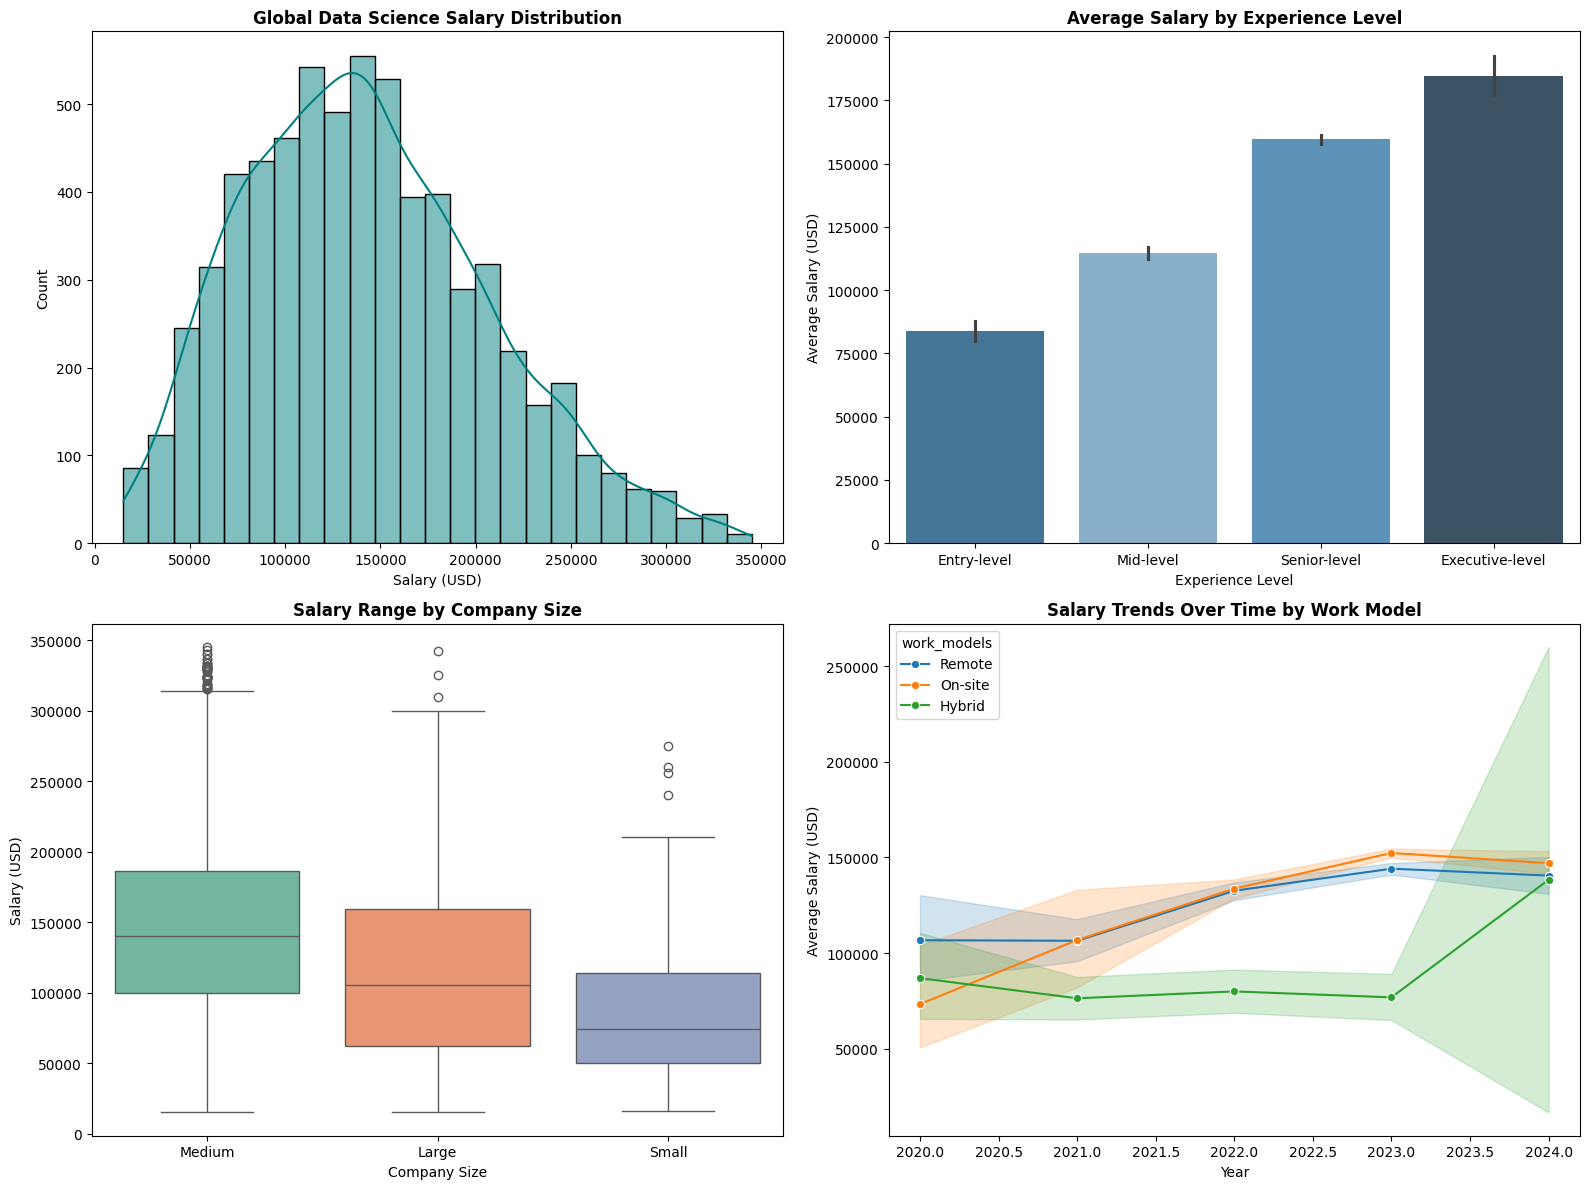

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

#plot 1
sns.histplot(data=df_filtered, x='salary_in_usd', bins=25, kde=True, color='teal', ax=ax1)
ax1.set_title("Global Data Science Salary Distribution", fontsize=12, fontweight='bold')
ax1.set_xlabel("Salary (USD)")
ax1.set_ylabel("Count")

#plot 2
exp_order = ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']
sns.barplot(
    data=df_filtered,
    x='experience_level',
    y='salary_in_usd',
    order=exp_order,
    hue='experience_level',
    palette='Blues_d',
    legend=False,
    ax=ax2
)
ax2.set_title("Average Salary by Experience Level", fontsize=12, fontweight='bold')
ax2.set_xlabel("Experience Level")
ax2.set_ylabel("Average Salary (USD)")

#plot 3
sns.boxplot(
    data=df_filtered,
    x='company_size',
    y='salary_in_usd',
    hue='company_size',
    palette='Set2',
    legend=False,
    ax=ax3
)
ax3.set_title("Salary Range by Company Size", fontsize=12, fontweight='bold')
ax3.set_xlabel("Company Size")
ax3.set_ylabel("Salary (USD)")

#plot 4
sns.lineplot(data=df_filtered, x='work_year', y='salary_in_usd', hue='work_models', marker='o', ax=ax4)
ax4.set_title("Salary Trends Over Time by Work Model", fontsize=12, fontweight='bold')
ax4.set_xlabel("Year")
ax4.set_ylabel("Average Salary (USD)")


plt.tight_layout()
plt.savefig('data_science_salary_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
